In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso

In [71]:
patients_data = pd.read_csv("Texture features.csv", index_col=0)

In [72]:
patients_data


,INFO_PatientID,INFO_ProcessDateOfTexture,INFO_SeriesDate,INFO_Series,INFO_ActualFrameDuration,INFO_NameOfRoi,CONVENTIONAL_SUVbwmin,CONVENTIONAL_SUVbwmean,CONVENTIONAL_SUVbwstd,CONVENTIONAL_SUVbwmax,...,GLZLM_HGZE,GLZLM_SZLGE,GLZLM_SZHGE,GLZLM_LZLGE,GLZLM_LZHGE,GLZLM_GLNU,GLZLM_ZLNU,GLZLM_ZP,TimePosition,zLocation[onlyFor2DROI]
INFO_PatientName,,,,,,,,,,,,,,,,,,,,,
LIFEX,LIFEx,Sun Jan 23 18:19:19 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,0.0,0.108004,0.319234,0.064479,0.476722,...,2.500000,0.000192,0.000585,2107.625000,11034.500000,1.000000,1.000000,0.016129,0.0,NaN
LIFEX,LIFEx,Sun Jan 23 18:19:20 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,1.0,2.910082,5.854704,1.387413,8.991810,...,363.808824,0.002428,208.152420,0.021055,3025.955882,4.323529,25.000000,0.482270,0.0,NaN
LIFEX,LIFEx,Sun Jan 23 18:38:58 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,0.0,0.188521,0.323404,0.057192,0.449061,...,2.000000,0.333484,0.333739,1242.000000,7367.000000,1.666667,1.000000,0.024793,0.0,NaN
LIFEX,LIFEx,Sun Jan 23 18:38:59 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,1.0,3.238746,5.991053,1.307934,8.991810,...,392.298246,0.001739,206.457640,0.021977,3172.052632,4.228070,16.614035,0.438462,0.0,NaN
LIFEX,LIFEx,Sun Jan 23 18:51:51 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,0.0,0.188521,0.323404,0.057192,0.449061,...,2.000000,0.333484,0.333739,1242.000000,7367.000000,1.666667,1.000000,0.024793,0.0,NaN
LIFEX,LIFEx,Sun Jan 23 18:51:52 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,1.0,3.238746,5.991053,1.307934,8.991810,...,392.298246,0.001739,206.457640,0.021977,3172.052632,4.228070,16.614035,0.438462,0.0,NaN
LIFEX,LIFEx,Sun Jan 23 19:07:19 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,0.0,0.191164,0.329256,0.058172,0.474525,...,2.500000,0.000357,0.001024,1151.125000,6418.000000,1.000000,1.000000,0.021505,0.0,NaN
LIFEX,LIFEx,Sun Jan 23 19:07:20 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,1.0,3.138171,5.955576,1.347132,8.987144,...,366.479167,0.002451,211.388504,0.019289,3109.687500,3.458333,18.666667,0.480000,0.0,NaN


In [73]:
label_encoder = LabelEncoder()
patients_data.iloc[:,0] = label_encoder.fit_transform(patients_data.iloc[:,0]).astype('float64')

In [74]:
corr = patients_data.corr()

<AxesSubplot:>

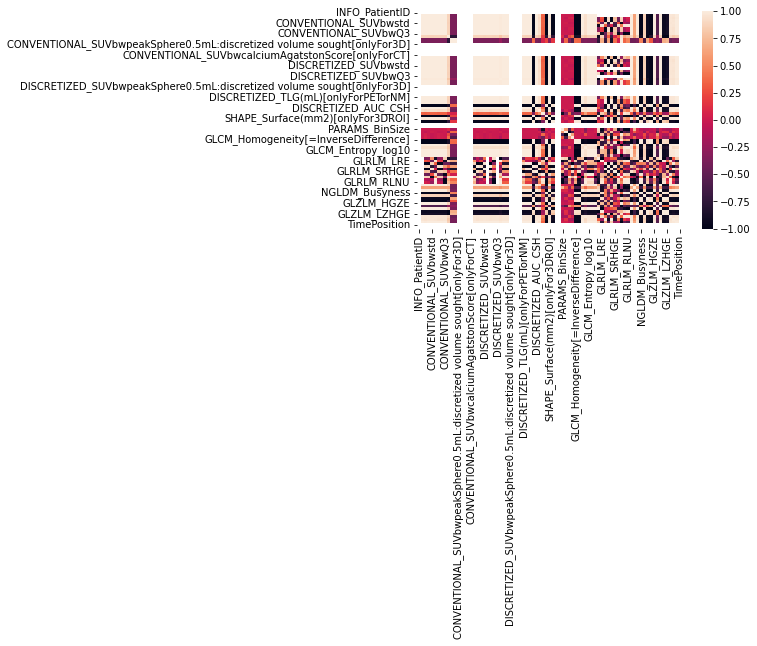

In [75]:
sns.heatmap(corr)

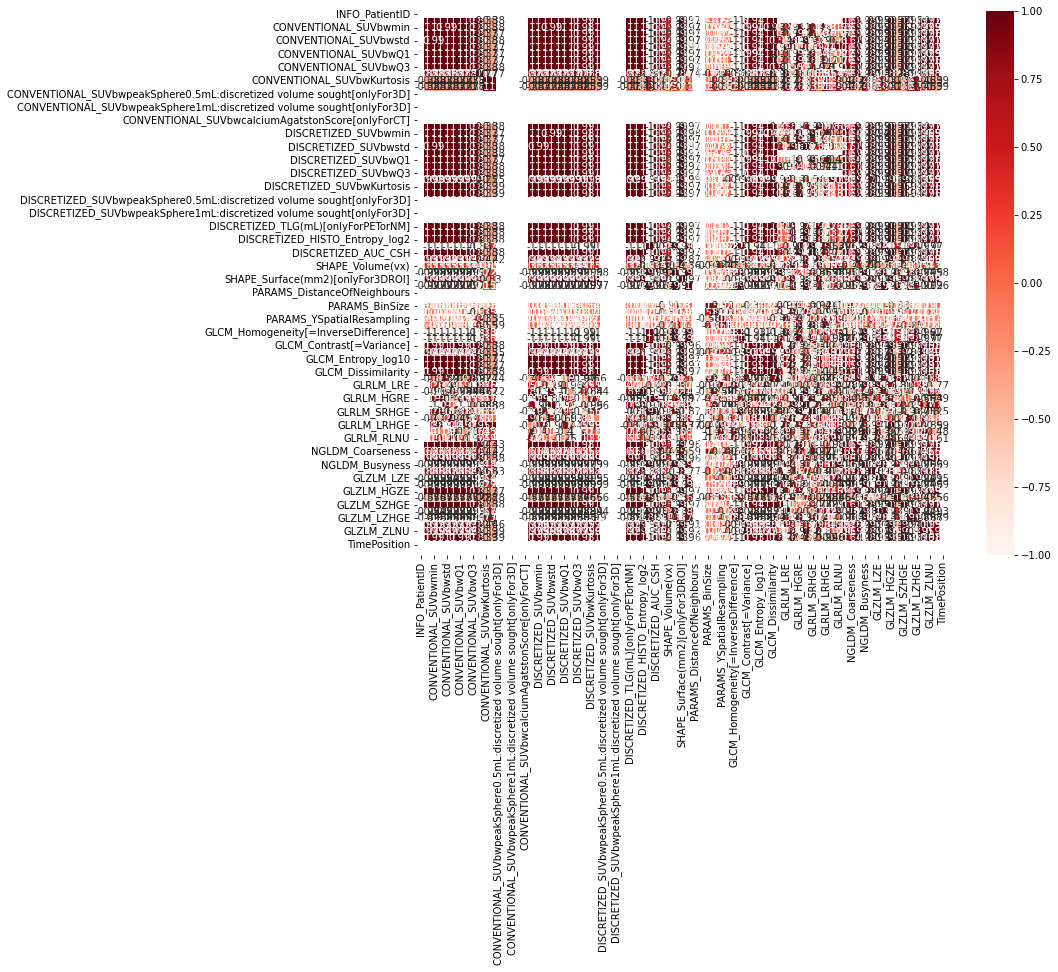

In [76]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap=plt.cm.Reds)
plt.show()

In [77]:
#Correlation with output variable
corr_target = abs(corr["GLZLM_LZLGE"])
#Selecting highly correlated features
relevant_features = corr_target[corr_target>0.5]
relevant_features

INFO_NameOfRoi                           0.933572
CONVENTIONAL_SUVbwmin                    0.937537
CONVENTIONAL_SUVbwmean                   0.933738
CONVENTIONAL_SUVbwstd                    0.931775
CONVENTIONAL_SUVbwmax                    0.933138
CONVENTIONAL_SUVbwQ1                     0.932256
CONVENTIONAL_SUVbwQ2                     0.933680
CONVENTIONAL_SUVbwQ3                     0.933385
CONVENTIONAL_SUVbwSkewness               0.986579
CONVENTIONAL_SUVbwKurtosis               0.674082
CONVENTIONAL_SUVbwExcessKurtosis         0.674082
CONVENTIONAL_TLG(mL)[onlyForPETorNM]     0.933686
DISCRETIZED_SUVbwmin                     0.931736
DISCRETIZED_SUVbwmean                    0.933713
DISCRETIZED_SUVbwstd                     0.932672
DISCRETIZED_SUVbwmax                     0.933572
DISCRETIZED_SUVbwQ1                      0.932868
DISCRETIZED_SUVbwQ2                      0.933423
DISCRETIZED_SUVbwQ3                      0.933572
DISCRETIZED_SUVbwSkewness                0.879892


In [81]:
print(patients_data[["CONVENTIONAL_SUVbwmin","CONVENTIONAL_SUVbwmean"]].corr())

                        CONVENTIONAL_SUVbwmin  CONVENTIONAL_SUVbwmean
CONVENTIONAL_SUVbwmin                1.000000                0.998622
CONVENTIONAL_SUVbwmean               0.998622                1.000000
